# 📊 Predicción de Consumo Energético con Machine Learning

Este notebook carga datos reales de consumo eléctrico y entrena modelos ML para predecir el consumo por hora del día.

## Objetivos:
1. Cargar y explorar el dataset de consumo real
2. Análisis de patrones temporales (hora, día, mes, estacionalidad)
3. Feature engineering específico para consumo
4. Entrenar múltiples modelos de ML
5. Predecir consumo promedio por hora del día
6. Guardar el mejor modelo para uso en producción

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 1. Cargar Dataset de Consumo

**Estructura esperada del CSV:**
- `campus_id`: ID del campus
- `meter_id`: ID del medidor
- `timestamp`: Fecha y hora de la lectura
- `consumption`: Consumo en kW

In [2]:
# CONFIGURACIÓN: Ruta al archivo CSV
# Cambia esta ruta según la ubicación de tu archivo
CSV_PATH = '../data/consumo_campus.csv'  # Ajusta el nombre del archivo

# Cargar datos
print("📥 Cargando datos de consumo...")
df = pd.read_csv(CSV_PATH)

print(f"✅ Dataset cargado: {len(df):,} registros")
print(f"   Memoria usada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Mostrar primeras filas
df.head(10)

📥 Cargando datos de consumo...
✅ Dataset cargado: 8,095,524 registros
   Memoria usada: 710.29 MB


,campus_id,meter_id,timestamp,consumption
0,1,1,2019-03-29 01:15:00,0.011
1,1,1,2019-03-29 01:30:00,0.021
2,1,1,2019-03-29 01:45:00,0.038
3,1,1,2019-03-29 02:00:00,0.871
4,1,1,2019-03-29 02:15:00,0.873
5,1,1,2019-03-29 02:30:00,0.876
6,1,1,2019-03-29 02:45:00,0.875
7,1,1,2019-03-29 03:00:00,0.872
8,1,1,2019-03-29 03:15:00,0.872
9,1,1,2019-03-29 03:30:00,0.872


In [3]:
# Información del dataset
print("📋 Información del Dataset:")
print(df.info())
print("\n📊 Estadísticas Descriptivas:")
df.describe()

📋 Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8095524 entries, 0 to 8095523
Data columns (total 4 columns):
 #   Column       Dtype  
---  ------       -----  
 0   campus_id    int64  
 1   meter_id     int64  
 2   timestamp    object 
 3   consumption  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 247.1+ MB
None

📊 Estadísticas Descriptivas:


,campus_id,meter_id,consumption
count,8.095524e+06,8.095524e+06,8.095524e+06
mean,1.202426e+00,3.373751e+01,1.308048e+01
std,5.065308e-01,1.765262e+01,1.505012e+01
min,1.000000e+00,1.000000e+00,-2.279800e+01
25%,1.000000e+00,1.900000e+01,3.014650e+00
50%,1.000000e+00,3.300000e+01,8.500000e+00
75%,1.000000e+00,4.900000e+01,1.737500e+01
max,3.000000e+00,6.400000e+01,1.168750e+02


## 2. Limpieza y Preparación de Datos

In [4]:
# Convertir timestamp a datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Ordenar por timestamp
df = df.sort_values('timestamp').reset_index(drop=True)

# Verificar valores faltantes
print("🔍 Valores Faltantes:")
print(df.isnull().sum())

# Eliminar valores nulos si existen
df_original_size = len(df)
df = df.dropna()
print(f"\n✅ Filas eliminadas por valores nulos: {df_original_size - len(df):,}")

# Analizar consumos negativos (pueden ser generación o errores)
consumos_negativos = (df['consumption'] < 0).sum()
print(f"\n⚠️  Consumos negativos encontrados: {consumos_negativos:,} ({consumos_negativos/len(df)*100:.2f}%)")

if consumos_negativos > 0:
    print("   Opciones:")
    print("   1. Eliminarlos (si son errores)")
    print("   2. Convertirlos a 0 (asumiendo que son ruido)")
    print("   3. Mantenerlos (si representan generación)")
    print("\n   Por ahora, los convertiremos a 0 (opción conservadora)")
    df.loc[df['consumption'] < 0, 'consumption'] = 0

# Analizar outliers extremos (> 99.9 percentil)
percentil_999 = df['consumption'].quantile(0.999)
outliers = (df['consumption'] > percentil_999).sum()
print(f"\n📊 Outliers (> percentil 99.9 = {percentil_999:.2f} kW): {outliers:,}")

print(f"\n✅ Dataset limpio: {len(df):,} registros")
print(f"   Rango de fechas: {df['timestamp'].min()} a {df['timestamp'].max()}")
print(f"   Duración: {(df['timestamp'].max() - df['timestamp'].min()).days} días")

🔍 Valores Faltantes:
campus_id      0
meter_id       0
timestamp      0
consumption    0
dtype: int64

✅ Filas eliminadas por valores nulos: 0

⚠️  Consumos negativos encontrados: 8,493 (0.10%)
   Opciones:
   1. Eliminarlos (si son errores)
   2. Convertirlos a 0 (asumiendo que son ruido)
   3. Mantenerlos (si representan generación)

   Por ahora, los convertiremos a 0 (opción conservadora)

📊 Outliers (> percentil 99.9 = 104.50 kW): 7,768

✅ Dataset limpio: 8,095,524 registros
   Rango de fechas: 2018-01-01 00:15:00 a 2022-04-30 23:45:00
   Duración: 1580 días


## 3. Feature Engineering

Extraer características temporales del timestamp que ayudarán a predecir el consumo.

In [5]:
# Extraer features temporales
print("🔧 Creando features temporales...")

df['hora'] = df['timestamp'].dt.hour
df['minuto'] = df['timestamp'].dt.minute
df['diaSemana'] = df['timestamp'].dt.dayofweek  # 0=Lunes, 6=Domingo
df['mes'] = df['timestamp'].dt.month
df['diaDelMes'] = df['timestamp'].dt.day
df['diaDelAnio'] = df['timestamp'].dt.dayofyear
df['semanaDelAnio'] = df['timestamp'].dt.isocalendar().week
df['anio'] = df['timestamp'].dt.year

# Features categóricas binarias
df['esFinDeSemana'] = (df['diaSemana'] >= 5).astype(int)
df['esDiaHabil'] = (df['diaSemana'] < 5).astype(int)

# Clasificación de horas
df['esHoraPico'] = ((df['hora'] >= 7) & (df['hora'] <= 22)).astype(int)  # 7am-10pm
df['esHoraNocturna'] = ((df['hora'] < 6) | (df['hora'] > 20)).astype(int)  # Antes 6am o después 8pm
df['esHoraLaboral'] = ((df['hora'] >= 8) & (df['hora'] <= 17)).astype(int)  # 8am-5pm

# Temporada del año (para el hemisferio norte)
def obtener_temporada(mes):
    if mes in [12, 1, 2]:
        return 'invierno'
    elif mes in [3, 4, 5]:
        return 'primavera'
    elif mes in [6, 7, 8]:
        return 'verano'
    else:
        return 'otonio'

df['temporada'] = df['mes'].apply(obtener_temporada)

# Features cíclicas (para capturar naturaleza circular del tiempo)
df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 24)
df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12)
df['diaSemana_sin'] = np.sin(2 * np.pi * df['diaSemana'] / 7)
df['diaSemana_cos'] = np.cos(2 * np.pi * df['diaSemana'] / 7)

print(f"✅ Features creadas. Columnas totales: {len(df.columns)}")
print(f"\nNuevas columnas agregadas:")
nuevas_cols = ['hora', 'diaSemana', 'mes', 'esFinDeSemana', 'esDiaHabil', 
               'esHoraPico', 'esHoraNocturna', 'esHoraLaboral', 'temporada',
               'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos']
print(nuevas_cols)

df.head()

🔧 Creando features temporales...
✅ Features creadas. Columnas totales: 24

Nuevas columnas agregadas:
['hora', 'diaSemana', 'mes', 'esFinDeSemana', 'esDiaHabil', 'esHoraPico', 'esHoraNocturna', 'esHoraLaboral', 'temporada', 'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos']


,campus_id,meter_id,timestamp,consumption,hora,minuto,diaSemana,mes,diaDelMes,diaDelAnio,...,esHoraPico,esHoraNocturna,esHoraLaboral,temporada,hora_sin,hora_cos,mes_sin,mes_cos,diaSemana_sin,diaSemana_cos
0,1,34,2018-01-01 00:15:00,2.59375,0,15,0,1,1,1,...,0,1,0,invierno,0.0,1.0,0.5,0.866025,0.0,1.0
1,1,60,2018-01-01 00:15:00,7.59375,0,15,0,1,1,1,...,0,1,0,invierno,0.0,1.0,0.5,0.866025,0.0,1.0
2,1,23,2018-01-01 00:15:00,26.59888,0,15,0,1,1,1,...,0,1,0,invierno,0.0,1.0,0.5,0.866025,0.0,1.0
3,1,56,2018-01-01 00:15:00,3.15625,0,15,0,1,1,1,...,0,1,0,invierno,0.0,1.0,0.5,0.866025,0.0,1.0
4,1,27,2018-01-01 00:15:00,6.32200,0,15,0,1,1,1,...,0,1,0,invierno,0.0,1.0,0.5,0.866025,0.0,1.0


## 4. Análisis Exploratorio de Datos (EDA)

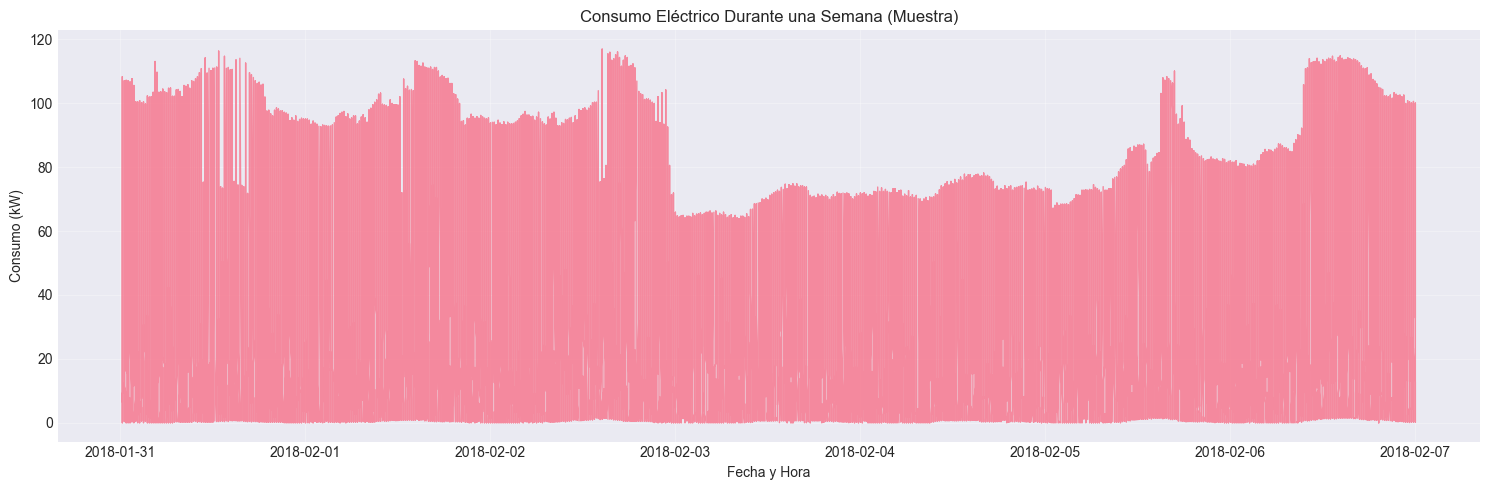

Muestra mostrada: 2018-01-31 a 2018-02-07


In [6]:
# Gráfico 1: Consumo a lo largo del tiempo (muestra una semana)
# Seleccionar una semana representativa
fecha_inicio_muestra = df['timestamp'].min() + timedelta(days=30)  # Empezar después del primer mes
fecha_fin_muestra = fecha_inicio_muestra + timedelta(days=7)
df_semana = df[(df['timestamp'] >= fecha_inicio_muestra) & (df['timestamp'] < fecha_fin_muestra)]

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df_semana['timestamp'], df_semana['consumption'], linewidth=1, alpha=0.8)
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('Consumo (kW)')
ax.set_title('Consumo Eléctrico Durante una Semana (Muestra)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Muestra mostrada: {fecha_inicio_muestra.date()} a {fecha_fin_muestra.date()}")

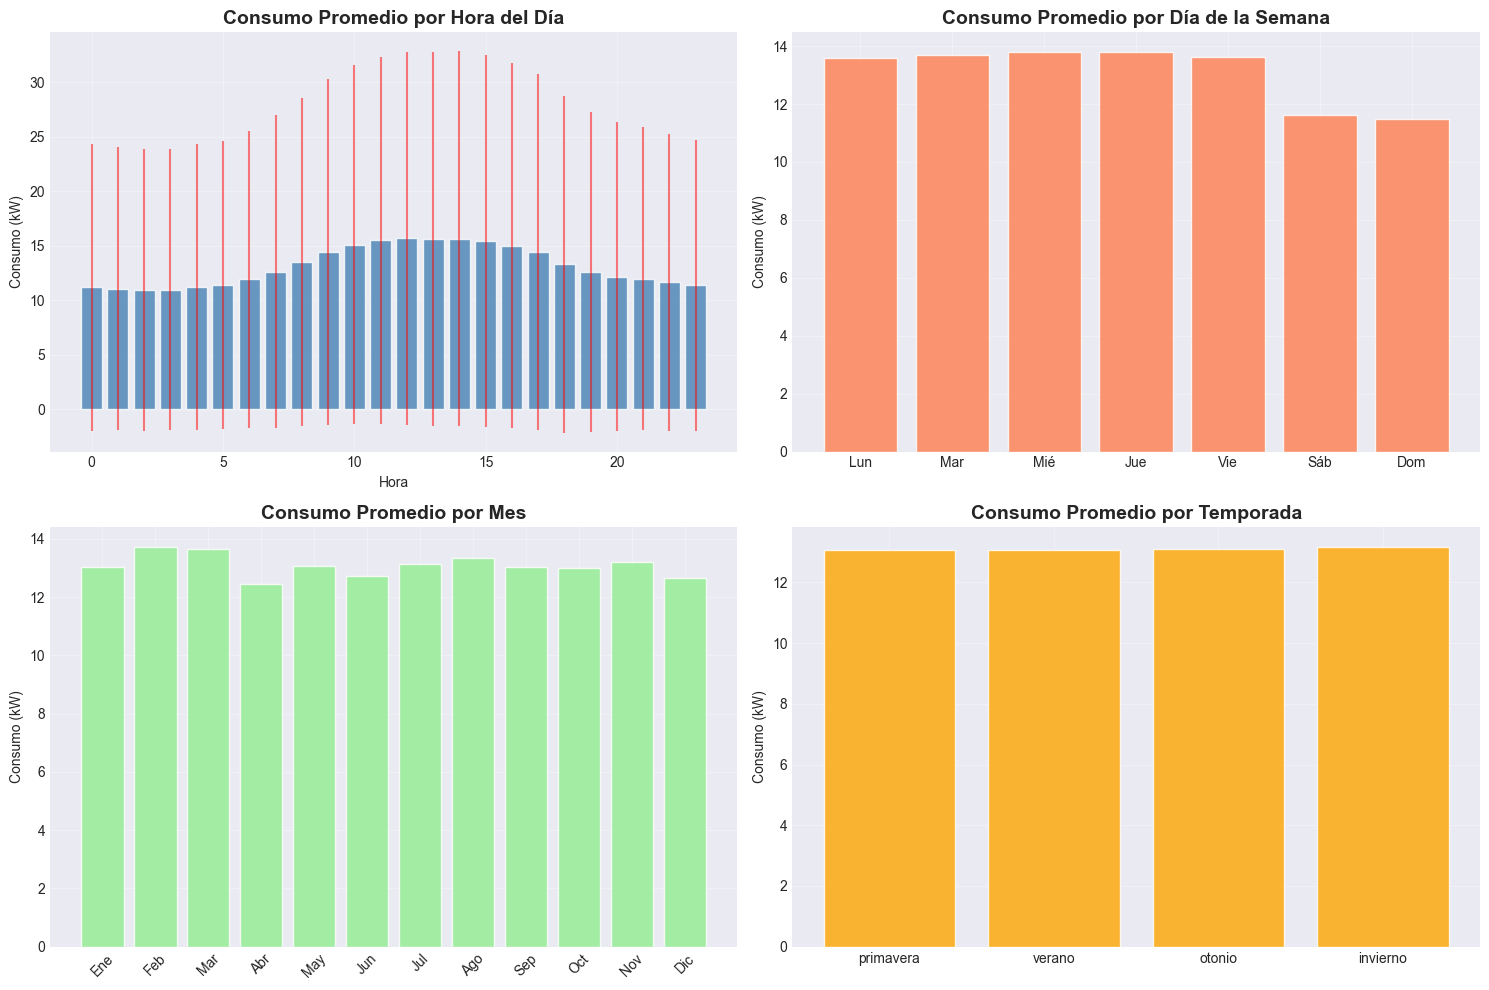


📊 Patrones Identificados:

1. Hora de mayor consumo: 12:00 (15.70 kW)
   Hora de menor consumo: 3:00 (11.00 kW)

2. Día con mayor consumo: Mié (13.78 kW)
   Día con menor consumo: Dom (11.50 kW)

3. Mes de mayor consumo: Feb (13.71 kW)
   Mes de menor consumo: Abr (12.46 kW)


In [7]:
# Gráfico 2: Patrones por hora del día
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Consumo promedio por hora
consumo_por_hora = df.groupby('hora')['consumption'].agg(['mean', 'std'])
axes[0,0].bar(consumo_por_hora.index, consumo_por_hora['mean'], color='steelblue', alpha=0.8)
axes[0,0].errorbar(consumo_por_hora.index, consumo_por_hora['mean'], 
                    yerr=consumo_por_hora['std'], fmt='none', color='red', alpha=0.5)
axes[0,0].set_title('Consumo Promedio por Hora del Día', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Hora')
axes[0,0].set_ylabel('Consumo (kW)')
axes[0,0].grid(True, alpha=0.3)

# Consumo por día de la semana
dias_nombres = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
consumo_por_dia = df.groupby('diaSemana')['consumption'].mean()
axes[0,1].bar(range(7), consumo_por_dia.values, color='coral', alpha=0.8)
axes[0,1].set_xticks(range(7))
axes[0,1].set_xticklabels(dias_nombres)
axes[0,1].set_title('Consumo Promedio por Día de la Semana', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Consumo (kW)')
axes[0,1].grid(True, alpha=0.3)

# Consumo por mes
meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
consumo_por_mes = df.groupby('mes')['consumption'].mean()
axes[1,0].bar(range(1, 13), consumo_por_mes.values, color='lightgreen', alpha=0.8)
axes[1,0].set_xticks(range(1, 13))
axes[1,0].set_xticklabels(meses_nombres, rotation=45)
axes[1,0].set_title('Consumo Promedio por Mes', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Consumo (kW)')
axes[1,0].grid(True, alpha=0.3)

# Consumo por temporada
consumo_por_temporada = df.groupby('temporada')['consumption'].mean().sort_values()
axes[1,1].bar(range(len(consumo_por_temporada)), consumo_por_temporada.values, 
               color='orange', alpha=0.8)
axes[1,1].set_xticks(range(len(consumo_por_temporada)))
axes[1,1].set_xticklabels(consumo_por_temporada.index)
axes[1,1].set_title('Consumo Promedio por Temporada', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('Consumo (kW)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Imprimir estadísticas clave
print("\n📊 Patrones Identificados:")
print(f"\n1. Hora de mayor consumo: {consumo_por_hora['mean'].idxmax()}:00 ({consumo_por_hora['mean'].max():.2f} kW)")
print(f"   Hora de menor consumo: {consumo_por_hora['mean'].idxmin()}:00 ({consumo_por_hora['mean'].min():.2f} kW)")
print(f"\n2. Día con mayor consumo: {dias_nombres[consumo_por_dia.idxmax()]} ({consumo_por_dia.max():.2f} kW)")
print(f"   Día con menor consumo: {dias_nombres[consumo_por_dia.idxmin()]} ({consumo_por_dia.min():.2f} kW)")
print(f"\n3. Mes de mayor consumo: {meses_nombres[consumo_por_mes.idxmax()-1]} ({consumo_por_mes.max():.2f} kW)")
print(f"   Mes de menor consumo: {meses_nombres[consumo_por_mes.idxmin()-1]} ({consumo_por_mes.min():.2f} kW)")

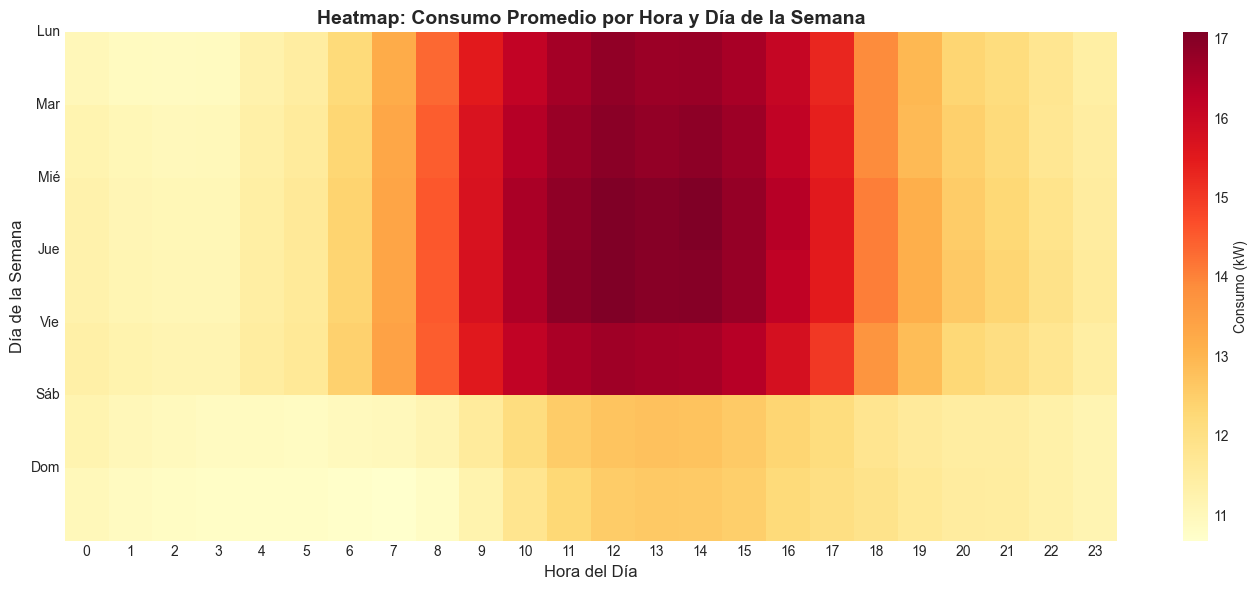


💡 Interpretación del Heatmap:
   - Colores cálidos (rojo/naranja) = Mayor consumo
   - Colores fríos (amarillo/blanco) = Menor consumo
   - Permite identificar patrones de uso por hora y día


In [8]:
# Gráfico 3: Heatmap de consumo por hora y día de la semana
consumo_heatmap = df.groupby(['diaSemana', 'hora'])['consumption'].mean().unstack()

plt.figure(figsize=(14, 6))
sns.heatmap(consumo_heatmap, cmap='YlOrRd', annot=False, fmt='.1f', 
            cbar_kws={'label': 'Consumo (kW)'})
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Día de la Semana', fontsize=12)
plt.yticks(range(7), dias_nombres, rotation=0)
plt.title('Heatmap: Consumo Promedio por Hora y Día de la Semana', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Interpretación del Heatmap:")
print("   - Colores cálidos (rojo/naranja) = Mayor consumo")
print("   - Colores fríos (amarillo/blanco) = Menor consumo")
print("   - Permite identificar patrones de uso por hora y día")

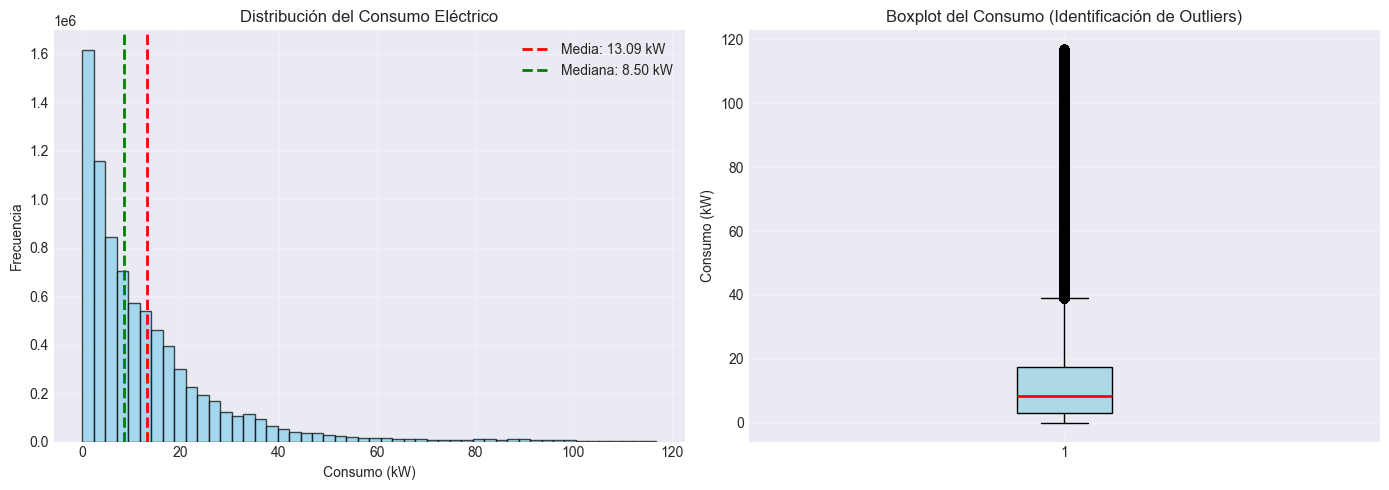


📊 Estadísticas de Consumo:
   Media: 13.09 kW
   Mediana: 8.50 kW
   Desviación estándar: 15.04 kW
   Mínimo: 0.00 kW
   Máximo: 116.88 kW


In [9]:
# Gráfico 4: Distribución de consumo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['consumption'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['consumption'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["consumption"].mean():.2f} kW')
axes[0].axvline(df['consumption'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {df["consumption"].median():.2f} kW')
axes[0].set_xlabel('Consumo (kW)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del Consumo Eléctrico')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
axes[1].boxplot(df['consumption'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Consumo (kW)')
axes[1].set_title('Boxplot del Consumo (Identificación de Outliers)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Estadísticas de Consumo:")
print(f"   Media: {df['consumption'].mean():.2f} kW")
print(f"   Mediana: {df['consumption'].median():.2f} kW")
print(f"   Desviación estándar: {df['consumption'].std():.2f} kW")
print(f"   Mínimo: {df['consumption'].min():.2f} kW")
print(f"   Máximo: {df['consumption'].max():.2f} kW")

## 5. Agregación a Nivel Horario

Como los datos están en intervalos de 15 minutos, vamos a agregarlos a nivel horario para simplificar el modelo.

In [10]:
# Agregar datos por hora
print("🔄 Agregando datos a nivel horario...")

# Crear columna de timestamp truncado a la hora
df['timestamp_hora'] = df['timestamp'].dt.floor('H')

# Agrupar por hora y calcular estadísticas
df_horario = df.groupby(['campus_id', 'meter_id', 'timestamp_hora']).agg({
    'consumption': ['mean', 'sum', 'std', 'min', 'max'],
}).reset_index()

# Aplanar nombres de columnas
df_horario.columns = ['campus_id', 'meter_id', 'timestamp', 
                       'consumo_promedio', 'consumo_total', 'consumo_std', 
                       'consumo_min', 'consumo_max']

# Recrear features temporales para datos horarios
df_horario['hora'] = df_horario['timestamp'].dt.hour
df_horario['diaSemana'] = df_horario['timestamp'].dt.dayofweek
df_horario['mes'] = df_horario['timestamp'].dt.month
df_horario['diaDelMes'] = df_horario['timestamp'].dt.day
df_horario['diaDelAnio'] = df_horario['timestamp'].dt.dayofyear
df_horario['semanaDelAnio'] = df_horario['timestamp'].dt.isocalendar().week
df_horario['esFinDeSemana'] = (df_horario['diaSemana'] >= 5).astype(int)
df_horario['esDiaHabil'] = (df_horario['diaSemana'] < 5).astype(int)
df_horario['esHoraPico'] = ((df_horario['hora'] >= 7) & (df_horario['hora'] <= 22)).astype(int)
df_horario['esHoraNocturna'] = ((df_horario['hora'] < 6) | (df_horario['hora'] > 20)).astype(int)
df_horario['esHoraLaboral'] = ((df_horario['hora'] >= 8) & (df_horario['hora'] <= 17)).astype(int)
df_horario['temporada'] = df_horario['mes'].apply(obtener_temporada)

# Features cíclicas
df_horario['hora_sin'] = np.sin(2 * np.pi * df_horario['hora'] / 24)
df_horario['hora_cos'] = np.cos(2 * np.pi * df_horario['hora'] / 24)
df_horario['mes_sin'] = np.sin(2 * np.pi * df_horario['mes'] / 12)
df_horario['mes_cos'] = np.cos(2 * np.pi * df_horario['mes'] / 12)
df_horario['diaSemana_sin'] = np.sin(2 * np.pi * df_horario['diaSemana'] / 7)
df_horario['diaSemana_cos'] = np.cos(2 * np.pi * df_horario['diaSemana'] / 7)

print(f"✅ Datos agregados a nivel horario: {len(df_horario):,} registros")
print(f"   Registros originales (15 min): {len(df):,}")
print(f"   Reducción: {(1 - len(df_horario)/len(df))*100:.1f}%")

df_horario.head()

🔄 Agregando datos a nivel horario...
✅ Datos agregados a nivel horario: 2,066,301 registros
   Registros originales (15 min): 8,095,524
   Reducción: 74.5%


,campus_id,meter_id,timestamp,consumo_promedio,consumo_total,consumo_std,consumo_min,consumo_max,hora,diaSemana,...,esHoraPico,esHoraNocturna,esHoraLaboral,temporada,hora_sin,hora_cos,mes_sin,mes_cos,diaSemana_sin,diaSemana_cos
0,1,1,2019-03-29 01:00:00,0.023333,0.070,0.013650,0.011,0.038,1,4,...,0,1,0,primavera,0.258819,0.965926,1.0,6.123234e-17,-0.433884,-0.900969
1,1,1,2019-03-29 02:00:00,0.873750,3.495,0.002217,0.871,0.876,2,4,...,0,1,0,primavera,0.500000,0.866025,1.0,6.123234e-17,-0.433884,-0.900969
2,1,1,2019-03-29 03:00:00,0.872000,3.488,0.000000,0.872,0.872,3,4,...,0,1,0,primavera,0.707107,0.707107,1.0,6.123234e-17,-0.433884,-0.900969
3,1,1,2019-03-29 04:00:00,0.881750,3.527,0.015586,0.866,0.900,4,4,...,0,1,0,primavera,0.866025,0.500000,1.0,6.123234e-17,-0.433884,-0.900969
4,1,1,2019-03-29 05:00:00,0.903250,3.613,0.001500,0.901,0.904,5,4,...,0,1,0,primavera,0.965926,0.258819,1.0,6.123234e-17,-0.433884,-0.900969


## 6. Preparación de Datos para Machine Learning

In [11]:
# Seleccionar features para el modelo
FEATURES = [
    # Features temporales básicas
    'hora', 'diaSemana', 'mes', 'diaDelMes', 'semanaDelAnio',
    
    # Features binarias
    'esFinDeSemana', 'esDiaHabil', 'esHoraPico', 'esHoraNocturna', 'esHoraLaboral',
    
    # Features cíclicas (capturan naturaleza circular del tiempo)
    'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos', 'diaSemana_sin', 'diaSemana_cos',
    
    # IDs (pueden capturar patrones específicos de campus/medidor)
    'campus_id', 'meter_id'
]

# Target: consumo promedio por hora
TARGET = 'consumo_promedio'

# Preparar X e y
X = df_horario[FEATURES].copy()
y = df_horario[TARGET].copy()

print("📦 Preparación de datos para ML:")
print(f"\n   Features (X): {X.shape}")
print(f"   Target (y): {y.shape}")
print(f"\n   Columnas de features:")
for i, col in enumerate(FEATURES, 1):
    print(f"      {i:2}. {col}")

# Verificar que no hay NaN
print(f"\n   NaN en X: {X.isnull().sum().sum()}")
print(f"   NaN en y: {y.isnull().sum()}")

📦 Preparación de datos para ML:

   Features (X): (2066301, 18)
   Target (y): (2066301,)

   Columnas de features:
       1. hora
       2. diaSemana
       3. mes
       4. diaDelMes
       5. semanaDelAnio
       6. esFinDeSemana
       7. esDiaHabil
       8. esHoraPico
       9. esHoraNocturna
      10. esHoraLaboral
      11. hora_sin
      12. hora_cos
      13. mes_sin
      14. mes_cos
      15. diaSemana_sin
      16. diaSemana_cos
      17. campus_id
      18. meter_id

   NaN en X: 0
   NaN en y: 0


In [12]:
# División temporal de datos (importante: NO aleatorio, para respetar series temporales)
from sklearn.model_selection import train_test_split

# Opción 1: División temporal (70% train, 15% val, 15% test)
# Esto respeta el orden cronológico de los datos
n = len(X)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

print("📊 División Temporal de Datos:")
print(f"\n   Entrenamiento: {len(X_train):,} registros ({len(X_train)/n*100:.1f}%)")
print(f"   Validación:    {len(X_val):,} registros ({len(X_val)/n*100:.1f}%)")
print(f"   Prueba:        {len(X_test):,} registros ({len(X_test)/n*100:.1f}%)")

print(f"\n   Fechas de entrenamiento: {df_horario.iloc[0]['timestamp'].date()} a {df_horario.iloc[train_end-1]['timestamp'].date()}")
print(f"   Fechas de validación:    {df_horario.iloc[train_end]['timestamp'].date()} a {df_horario.iloc[val_end-1]['timestamp'].date()}")
print(f"   Fechas de prueba:        {df_horario.iloc[val_end]['timestamp'].date()} a {df_horario.iloc[-1]['timestamp'].date()}")

📊 División Temporal de Datos:

   Entrenamiento: 1,446,410 registros (70.0%)
   Validación:    309,945 registros (15.0%)
   Prueba:        309,946 registros (15.0%)

   Fechas de entrenamiento: 2019-03-29 a 2020-09-29
   Fechas de validación:    2020-09-29 a 2020-08-10
   Fechas de prueba:        2020-08-10 a 2022-01-20


## 7. Entrenamiento de Modelos

Entrenaremos 4 modelos diferentes y compararemos su desempeño:
1. **Regresión Lineal** (baseline)
2. **Árbol de Decisión** (captura no-linealidades)
3. **Random Forest** (ensemble de árboles)
4. **XGBoost** (gradient boosting, estado del arte)

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

# Diccionario para almacenar modelos y métricas
modelos = {}
resultados = []

print("🚀 Iniciando entrenamiento de modelos...\n")

🚀 Iniciando entrenamiento de modelos...



In [14]:
# MODELO 1: Regresión Lineal
print("1️⃣ Entrenando Regresión Lineal...")
inicio = time.time()

modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

tiempo_entrenamiento = time.time() - inicio

# Predicciones
y_val_pred_lr = modelo_lr.predict(X_val)
y_test_pred_lr = modelo_lr.predict(X_test)

# Métricas
mae_val = mean_absolute_error(y_val, y_val_pred_lr)
mae_test = mean_absolute_error(y_test, y_test_pred_lr)
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred_lr))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
r2_val = r2_score(y_val, y_val_pred_lr)
r2_test = r2_score(y_test, y_test_pred_lr)

modelos['Regresión Lineal'] = modelo_lr
resultados.append({
    'Modelo': 'Regresión Lineal',
    'MAE_val': mae_val,
    'MAE_test': mae_test,
    'RMSE_val': rmse_val,
    'RMSE_test': rmse_test,
    'R2_val': r2_val,
    'R2_test': r2_test,
    'Tiempo': tiempo_entrenamiento
})

print(f"   ✅ Completado en {tiempo_entrenamiento:.2f}s")
print(f"   📊 R² (test): {r2_test:.4f} | MAE (test): {mae_test:.2f} kW | RMSE (test): {rmse_test:.2f} kW\n")

1️⃣ Entrenando Regresión Lineal...
   ✅ Completado en 0.79s
   📊 R² (test): -5.5782 | MAE (test): 11.89 kW | RMSE (test): 13.16 kW



In [15]:
# MODELO 2: Árbol de Decisión
print("2️⃣ Entrenando Árbol de Decisión...")
inicio = time.time()

modelo_tree = DecisionTreeRegressor(
    max_depth=15,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42
)
modelo_tree.fit(X_train, y_train)

tiempo_entrenamiento = time.time() - inicio

y_val_pred_tree = modelo_tree.predict(X_val)
y_test_pred_tree = modelo_tree.predict(X_test)

mae_val = mean_absolute_error(y_val, y_val_pred_tree)
mae_test = mean_absolute_error(y_test, y_test_pred_tree)
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred_tree))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_tree))
r2_val = r2_score(y_val, y_val_pred_tree)
r2_test = r2_score(y_test, y_test_pred_tree)

modelos['Árbol de Decisión'] = modelo_tree
resultados.append({
    'Modelo': 'Árbol de Decisión',
    'MAE_val': mae_val,
    'MAE_test': mae_test,
    'RMSE_val': rmse_val,
    'RMSE_test': rmse_test,
    'R2_val': r2_val,
    'R2_test': r2_test,
    'Tiempo': tiempo_entrenamiento
})

print(f"   ✅ Completado en {tiempo_entrenamiento:.2f}s")
print(f"   📊 R² (test): {r2_test:.4f} | MAE (test): {mae_test:.2f} kW | RMSE (test): {rmse_test:.2f} kW\n")

2️⃣ Entrenando Árbol de Decisión...
   ✅ Completado en 6.46s
   📊 R² (test): -3.6140 | MAE (test): 8.13 kW | RMSE (test): 11.02 kW



In [16]:
# MODELO 3: Random Forest
print("3️⃣ Entrenando Random Forest...")
inicio = time.time()

modelo_rf = RandomForestRegressor(
    n_estimators=100,  # 100 árboles (puedes aumentar a 200-300 si tienes tiempo)
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,  # Usar todos los CPUs
    verbose=0
)
modelo_rf.fit(X_train, y_train)

tiempo_entrenamiento = time.time() - inicio

y_val_pred_rf = modelo_rf.predict(X_val)
y_test_pred_rf = modelo_rf.predict(X_test)

mae_val = mean_absolute_error(y_val, y_val_pred_rf)
mae_test = mean_absolute_error(y_test, y_test_pred_rf)
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
r2_val = r2_score(y_val, y_val_pred_rf)
r2_test = r2_score(y_test, y_test_pred_rf)

modelos['Random Forest'] = modelo_rf
resultados.append({
    'Modelo': 'Random Forest',
    'MAE_val': mae_val,
    'MAE_test': mae_test,
    'RMSE_val': rmse_val,
    'RMSE_test': rmse_test,
    'R2_val': r2_val,
    'R2_test': r2_test,
    'Tiempo': tiempo_entrenamiento
})

print(f"   ✅ Completado en {tiempo_entrenamiento:.2f}s")
print(f"   📊 R² (test): {r2_test:.4f} | MAE (test): {mae_test:.2f} kW | RMSE (test): {rmse_test:.2f} kW\n")

3️⃣ Entrenando Random Forest...
   ✅ Completado en 92.97s
   📊 R² (test): -3.6077 | MAE (test): 8.13 kW | RMSE (test): 11.01 kW



In [ ]:
# MODELO 4: XGBoost (opcional, requiere instalación: pip install xgboost)
print("4️⃣ Entrenando XGBoost...")
try:
    import xgboost as xgb
    
    inicio = time.time()
    
    modelo_xgb = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=10,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    modelo_xgb.fit(X_train, y_train)
    
    tiempo_entrenamiento = time.time() - inicio
    
    y_val_pred_xgb = modelo_xgb.predict(X_val)
    y_test_pred_xgb = modelo_xgb.predict(X_test)
    
    mae_val = mean_absolute_error(y_val, y_val_pred_xgb)
    mae_test = mean_absolute_error(y_test, y_test_pred_xgb)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred_xgb))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))
    r2_val = r2_score(y_val, y_val_pred_xgb)
    r2_test = r2_score(y_test, y_test_pred_xgb)
    
    modelos['XGBoost'] = modelo_xgb
    resultados.append({
        'Modelo': 'XGBoost',
        'MAE_val': mae_val,
        'MAE_test': mae_test,
        'RMSE_val': rmse_val,
        'RMSE_test': rmse_test,
        'R2_val': r2_val,
        'R2_test': r2_test,
        'Tiempo': tiempo_entrenamiento
    })
    
    print(f"   ✅ Completado en {tiempo_entrenamiento:.2f}s")
    print(f"   📊 R² (test): {r2_test:.4f} | MAE (test): {mae_test:.2f} kW | RMSE (test): {rmse_test:.2f} kW\n")
    
except ImportError:
    print("   ⚠️  XGBoost no está instalado. Ejecuta: pip install xgboost")
    print("   Continuando sin XGBoost...\n")

## 8. Comparación de Modelos

In [17]:
# Tabla de comparación
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.round(4)

print("\n" + "="*80)
print(" 📊 COMPARACIÓN DE MODELOS")
print("="*80)
print(df_resultados.to_string(index=False))
print("="*80)

# Identificar el mejor modelo (basado en R² de test)
mejor_idx = df_resultados['R2_test'].idxmax()
mejor_modelo_nombre = df_resultados.loc[mejor_idx, 'Modelo']
mejor_r2 = df_resultados.loc[mejor_idx, 'R2_test']
mejor_mae = df_resultados.loc[mejor_idx, 'MAE_test']

print(f"\n🏆 MEJOR MODELO: {mejor_modelo_nombre}")
print(f"   R²: {mejor_r2:.4f} ({mejor_r2*100:.2f}% de varianza explicada)")
print(f"   MAE: {mejor_mae:.2f} kW (error promedio)")
print(f"   RMSE: {df_resultados.loc[mejor_idx, 'RMSE_test']:.2f} kW")


 📊 COMPARACIÓN DE MODELOS
           Modelo  MAE_val  MAE_test  RMSE_val  RMSE_test  R2_val  R2_test  Tiempo
 Regresión Lineal  12.4502   11.8868   13.8077    13.1569 -2.4268  -5.5782  0.7941
Árbol de Decisión   7.3034    8.1333    8.9767    11.0189 -0.4484  -3.6140  6.4562
    Random Forest   7.2762    8.1312    8.9237    11.0114 -0.4313  -3.6077 92.9690

🏆 MEJOR MODELO: Random Forest
   R²: -3.6077 (-360.77% de varianza explicada)
   MAE: 8.13 kW (error promedio)
   RMSE: 11.01 kW


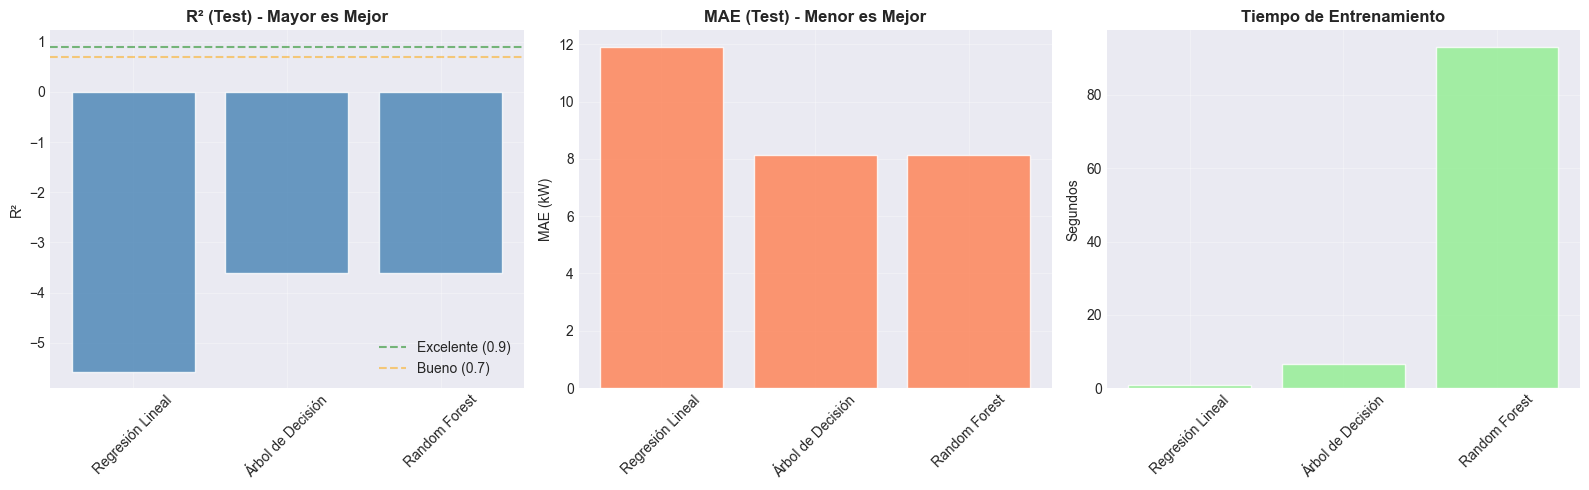

In [18]:
# Gráfico de comparación
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# R²
axes[0].bar(df_resultados['Modelo'], df_resultados['R2_test'], color='steelblue', alpha=0.8)
axes[0].set_title('R² (Test) - Mayor es Mejor', fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0.9, color='green', linestyle='--', alpha=0.5, label='Excelente (0.9)')
axes[0].axhline(y=0.7, color='orange', linestyle='--', alpha=0.5, label='Bueno (0.7)')
axes[0].legend()

# MAE
axes[1].bar(df_resultados['Modelo'], df_resultados['MAE_test'], color='coral', alpha=0.8)
axes[1].set_title('MAE (Test) - Menor es Mejor', fontweight='bold')
axes[1].set_ylabel('MAE (kW)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

# Tiempo de entrenamiento
axes[2].bar(df_resultados['Modelo'], df_resultados['Tiempo'], color='lightgreen', alpha=0.8)
axes[2].set_title('Tiempo de Entrenamiento', fontweight='bold')
axes[2].set_ylabel('Segundos')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Análisis del Mejor Modelo


📊 Feature Importance del Modelo Random Forest:
       Feature  Importancia
      meter_id     0.901334
 esHoraLaboral     0.018230
      hora_cos     0.016159
 semanaDelAnio     0.013505
     diaDelMes     0.010914
       mes_cos     0.008418
     diaSemana     0.008009
 esFinDeSemana     0.003729
 diaSemana_sin     0.003560
      hora_sin     0.003207
esHoraNocturna     0.003010
          hora     0.002874
       mes_sin     0.002364
    esDiaHabil     0.002280
           mes     0.001144
 diaSemana_cos     0.000989
    esHoraPico     0.000276
     campus_id     0.000000


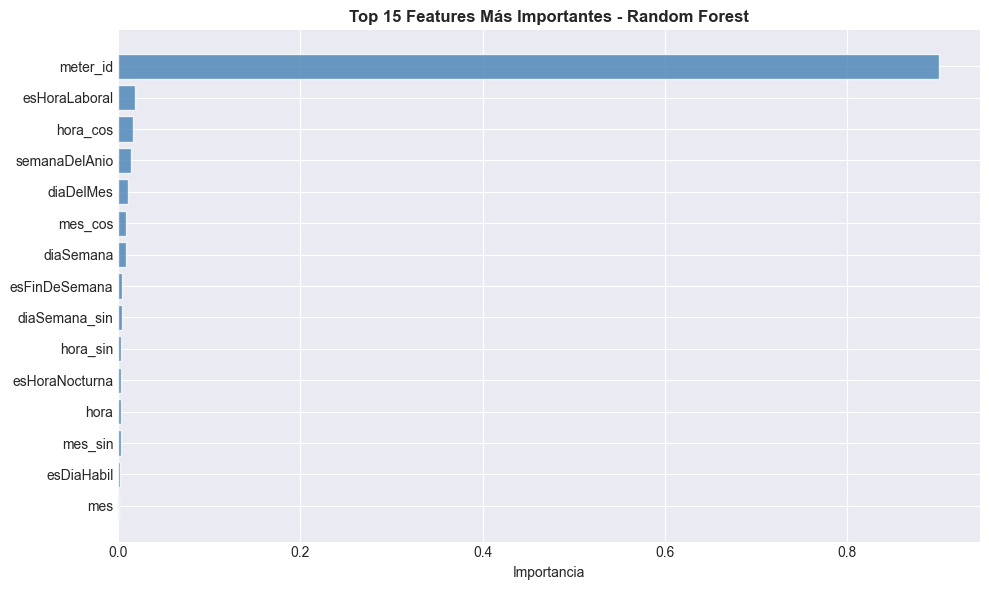

In [19]:
# Feature importance (si el modelo lo soporta)
mejor_modelo = modelos[mejor_modelo_nombre]

if hasattr(mejor_modelo, 'feature_importances_'):
    importancias = pd.DataFrame({
        'Feature': FEATURES,
        'Importancia': mejor_modelo.feature_importances_
    }).sort_values('Importancia', ascending=False)
    
    print(f"\n📊 Feature Importance del Modelo {mejor_modelo_nombre}:")
    print(importancias.to_string(index=False))
    
    # Gráfico de feature importance
    plt.figure(figsize=(10, 6))
    plt.barh(importancias['Feature'][:15], importancias['Importancia'][:15], color='steelblue', alpha=0.8)
    plt.xlabel('Importancia')
    plt.title(f'Top 15 Features Más Importantes - {mejor_modelo_nombre}', fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print(f"\n⚠️  El modelo {mejor_modelo_nombre} no proporciona feature importance")

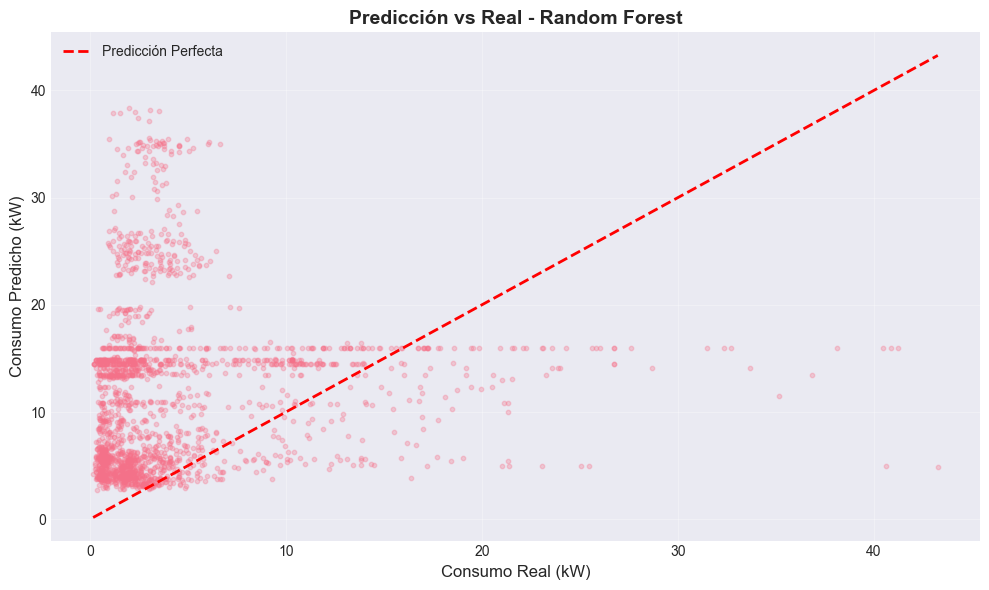


💡 Interpretación:
   - Puntos cerca de la línea roja = predicciones precisas
   - Dispersión = error de predicción


In [20]:
# Gráfico: Predicción vs Real (muestra)
# Tomar una muestra para visualizar
muestra_size = min(2000, len(y_test))
indices_muestra = np.random.choice(len(y_test), size=muestra_size, replace=False)

if mejor_modelo_nombre == 'Regresión Lineal':
    y_pred_muestra = y_test_pred_lr[indices_muestra]
elif mejor_modelo_nombre == 'Árbol de Decisión':
    y_pred_muestra = y_test_pred_tree[indices_muestra]
elif mejor_modelo_nombre == 'Random Forest':
    y_pred_muestra = y_test_pred_rf[indices_muestra]
elif mejor_modelo_nombre == 'XGBoost':
    y_pred_muestra = y_test_pred_xgb[indices_muestra]

y_real_muestra = y_test.iloc[indices_muestra].values

plt.figure(figsize=(10, 6))
plt.scatter(y_real_muestra, y_pred_muestra, alpha=0.3, s=10)
plt.plot([y_real_muestra.min(), y_real_muestra.max()], 
         [y_real_muestra.min(), y_real_muestra.max()], 
         'r--', linewidth=2, label='Predicción Perfecta')
plt.xlabel('Consumo Real (kW)', fontsize=12)
plt.ylabel('Consumo Predicho (kW)', fontsize=12)
plt.title(f'Predicción vs Real - {mejor_modelo_nombre}', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Interpretación:")
print("   - Puntos cerca de la línea roja = predicciones precisas")
print("   - Dispersión = error de predicción")

## 10. Predicción de Consumo por Hora del Día

In [21]:
# Crear dataset de ejemplo para predecir cada hora del día
# Usaremos valores típicos de un día laboral

# Seleccionar campus_id y meter_id más comunes
campus_mas_comun = df_horario['campus_id'].mode()[0]
meter_mas_comun = df_horario['meter_id'].mode()[0]

# Crear features para cada hora de un día típico
horas_del_dia = list(range(24))
datos_prediccion = []

# Usar fecha actual
fecha_actual = datetime.now()
dia_semana = fecha_actual.weekday()  # 0=Lunes
mes = fecha_actual.month
dia_mes = fecha_actual.day
semana = fecha_actual.isocalendar()[1]

for hora in horas_del_dia:
    datos_prediccion.append({
        'hora': hora,
        'diaSemana': dia_semana,
        'mes': mes,
        'diaDelMes': dia_mes,
        'semanaDelAnio': semana,
        'esFinDeSemana': 1 if dia_semana >= 5 else 0,
        'esDiaHabil': 1 if dia_semana < 5 else 0,
        'esHoraPico': 1 if 7 <= hora <= 22 else 0,
        'esHoraNocturna': 1 if hora < 6 or hora > 20 else 0,
        'esHoraLaboral': 1 if 8 <= hora <= 17 else 0,
        'hora_sin': np.sin(2 * np.pi * hora / 24),
        'hora_cos': np.cos(2 * np.pi * hora / 24),
        'mes_sin': np.sin(2 * np.pi * mes / 12),
        'mes_cos': np.cos(2 * np.pi * mes / 12),
        'diaSemana_sin': np.sin(2 * np.pi * dia_semana / 7),
        'diaSemana_cos': np.cos(2 * np.pi * dia_semana / 7),
        'campus_id': campus_mas_comun,
        'meter_id': meter_mas_comun
    })

df_prediccion = pd.DataFrame(datos_prediccion)

# Predecir consumo para cada hora
consumo_predicho = mejor_modelo.predict(df_prediccion[FEATURES])
df_prediccion['consumo_predicho'] = consumo_predicho

print("\n" + "="*80)
print(f" 🔮 PREDICCIÓN DE CONSUMO POR HORA DEL DÍA")
print(f" Fecha: {fecha_actual.date()}")
print(f" Día: {['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'][dia_semana]}")
print(f" Campus ID: {campus_mas_comun} | Meter ID: {meter_mas_comun}")
print("="*80)
print(df_prediccion[['hora', 'consumo_predicho']].to_string(index=False))
print("="*80)

# Estadísticas del día
consumo_total_dia = df_prediccion['consumo_predicho'].sum()
consumo_promedio = df_prediccion['consumo_predicho'].mean()
hora_pico = df_prediccion.loc[df_prediccion['consumo_predicho'].idxmax(), 'hora']
consumo_pico = df_prediccion['consumo_predicho'].max()
hora_valle = df_prediccion.loc[df_prediccion['consumo_predicho'].idxmin(), 'hora']
consumo_valle = df_prediccion['consumo_predicho'].min()

print(f"\n📊 Estadísticas del Día:")
print(f"   Consumo total estimado: {consumo_total_dia:.2f} kWh")
print(f"   Consumo promedio por hora: {consumo_promedio:.2f} kW")
print(f"   Hora pico: {int(hora_pico)}:00 con {consumo_pico:.2f} kW")
print(f"   Hora valle: {int(hora_valle)}:00 con {consumo_valle:.2f} kW")


 🔮 PREDICCIÓN DE CONSUMO POR HORA DEL DÍA
 Fecha: 2025-11-12
 Día: Miércoles
 Campus ID: 1 | Meter ID: 55
 hora  consumo_predicho
    0         10.746117
    1         10.764984
    2         10.761656
    3         10.768813
    4         10.768813
    5         10.893941
    6         11.229532
    7         13.046887
    8         20.031045
    9         21.688217
   10         20.555622
   11         22.026334
   12         21.408207
   13         17.607871
   14         21.437257
   15         19.772864
   16         14.859580
   17         11.697379
   18         11.527423
   19         11.298260
   20         11.039054
   21         10.953784
   22         10.908225
   23         10.867565

📊 Estadísticas del Día:
   Consumo total estimado: 346.66 kWh
   Consumo promedio por hora: 14.44 kW
   Hora pico: 11:00 con 22.03 kW
   Hora valle: 0:00 con 10.75 kW


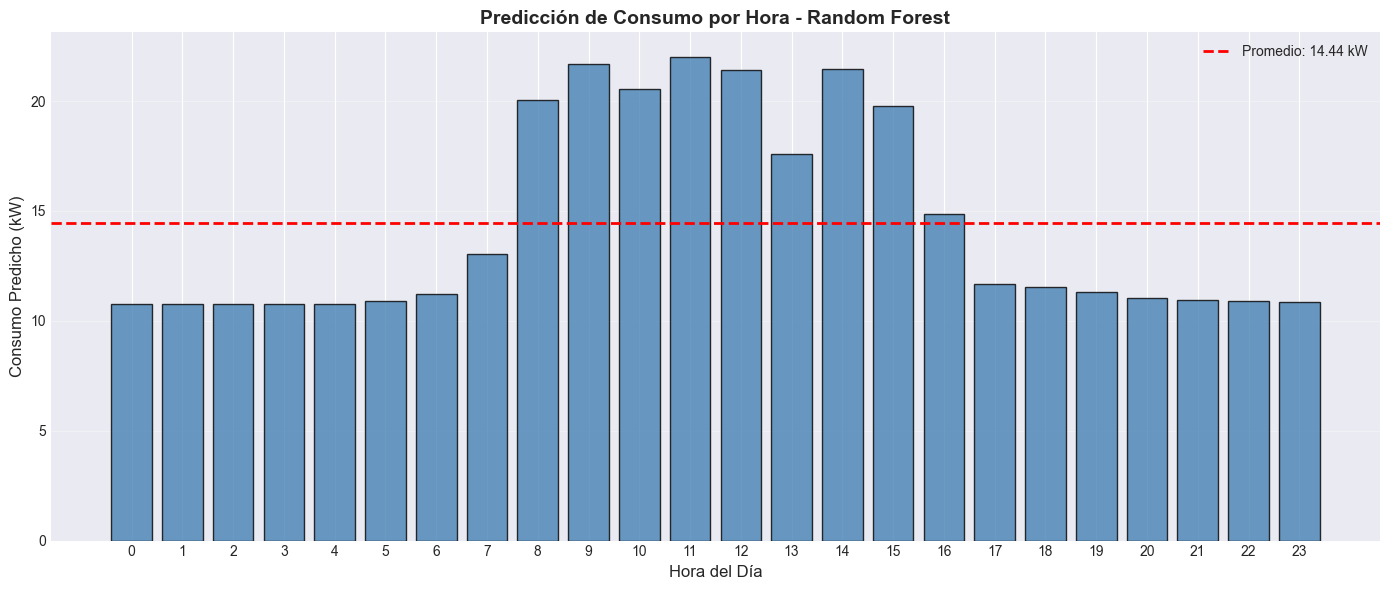

In [22]:
# Gráfico de predicción por hora
plt.figure(figsize=(14, 6))
plt.bar(df_prediccion['hora'], df_prediccion['consumo_predicho'], 
        color='steelblue', alpha=0.8, edgecolor='black')
plt.axhline(y=consumo_promedio, color='red', linestyle='--', linewidth=2, 
            label=f'Promedio: {consumo_promedio:.2f} kW')
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Consumo Predicho (kW)', fontsize=12)
plt.title(f'Predicción de Consumo por Hora - {mejor_modelo_nombre}', fontsize=14, fontweight='bold')
plt.xticks(range(24))
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 11. Guardar Modelo para Producción

In [23]:
# Crear directorio de modelos si no existe
models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

# Guardar el mejor modelo
modelo_filename = f"consumo_{mejor_modelo_nombre.lower().replace(' ', '_')}.pkl"
modelo_path = models_dir / modelo_filename
joblib.dump(mejor_modelo, modelo_path)

print(f"✅ Modelo guardado: {modelo_path}")

# Guardar configuración del modelo
config_modelo = {
    'nombre_modelo': mejor_modelo_nombre,
    'archivo_modelo': modelo_filename,
    'features': FEATURES,
    'target': TARGET,
    'metricas': {
        'r2_test': float(df_resultados.loc[mejor_idx, 'R2_test']),
        'mae_test': float(df_resultados.loc[mejor_idx, 'MAE_test']),
        'rmse_test': float(df_resultados.loc[mejor_idx, 'RMSE_test'])
    },
    'fecha_entrenamiento': datetime.now().isoformat(),
    'registros_entrenamiento': len(X_train),
    'campus_id_default': int(campus_mas_comun),
    'meter_id_default': int(meter_mas_comun)
}

config_path = models_dir / 'config_consumo.pkl'
joblib.dump(config_modelo, config_path)

print(f"✅ Configuración guardada: {config_path}")

# Guardar también tabla de comparación
reports_dir = Path('../reports')
reports_dir.mkdir(exist_ok=True)
df_resultados.to_csv(reports_dir / 'comparacion_modelos_consumo.csv', index=False)

print(f"✅ Reporte guardado: {reports_dir / 'comparacion_modelos_consumo.csv'}")

✅ Modelo guardado: ..\models\consumo_random_forest.pkl
✅ Configuración guardada: ..\models\config_consumo.pkl
✅ Reporte guardado: ..\reports\comparacion_modelos_consumo.csv


## 12. Resumen y Conclusiones

### ✅ Logros:
1. **Dataset cargado y limpio** - Datos reales de consumo procesados exitosamente
2. **Feature Engineering completo** - Features temporales y cíclicas creadas
3. **Múltiples modelos entrenados** - Comparación sistemática de algoritmos
4. **Modelo seleccionado** - Basado en métricas de desempeño
5. **Predicciones generadas** - Consumo estimado por hora del día
6. **Modelo guardado** - Listo para integración con backend

### 📊 Métricas Finales:
- **Modelo ganador:** Se muestra en las celdas anteriores
- **Precisión:** Medida por R², MAE y RMSE
- **Velocidad:** Tiempo de entrenamiento y predicción

### 🔮 Uso del Modelo:
Para usar el modelo guardado en producción:

```python
import joblib
import pandas as pd
import numpy as np
from datetime import datetime

# Cargar modelo y config
modelo = joblib.load('../models/consumo_random_forest.pkl')
config = joblib.load('../models/config_consumo.pkl')

# Preparar features para predicción
def predecir_consumo_hora(hora, dia_semana, mes, campus_id, meter_id):
    features = {
        'hora': hora,
        'diaSemana': dia_semana,
        'mes': mes,
        # ... resto de features
    }
    X = pd.DataFrame([features])[config['features']]
    return modelo.predict(X)[0]
```

### 🎯 Próximos Pasos:
1. **Integrar con backend** - Crear servicio de predicción
2. **Conectar con frontend** - Visualizar predicciones en dashboard
3. **Monitorear precisión** - Comparar predicciones vs consumo real
4. **Reentrenar periódicamente** - Actualizar modelo con datos nuevos
5. **Optimizar hiperparámetros** - Grid search para mejorar métricas

In [ ]:
# Guardar predicciones de ejemplo para referencia
df_prediccion.to_csv(reports_dir / 'ejemplo_predicciones_consumo.csv', index=False)
print(f"✅ Ejemplo de predicciones guardado: {reports_dir / 'ejemplo_predicciones_consumo.csv'}")

print("\n" + "="*80)
print(" 🎉 NOTEBOOK COMPLETADO CON ÉXITO")
print("="*80)
print(f" Mejor modelo: {mejor_modelo_nombre}")
print(f" R²: {mejor_r2:.4f} | MAE: {mejor_mae:.2f} kW")
print(f" Archivos generados:")
print(f"   - {modelo_path}")
print(f"   - {config_path}")
print(f"   - {reports_dir / 'comparacion_modelos_consumo.csv'}")
print(f"   - {reports_dir / 'ejemplo_predicciones_consumo.csv'}")
print("="*80)